In [2]:
!pip install -q imblearn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
df = pd.read_csv('/content/filtered_mental_health_24plus_employed.csv')
df['mental_health_risk'] = df['mental_health_risk'].map({'High':2, 'Medium':1, 'Low':0})


print(df.head())

   age      gender employment_status work_environment mental_health_history  \
0   56        Male          Employed          On-site                   Yes   
1   32      Female          Employed          On-site                   Yes   
2   56  Non-binary          Employed           Remote                    No   
3   40        Male          Employed           Hybrid                    No   
4   28      Female          Employed           Remote                    No   

  seeks_treatment  stress_level  sleep_hours  physical_activity_days  \
0             Yes             6          6.2                       3   
1              No             7          7.7                       2   
2             Yes             2          5.5                       1   
3              No             7          6.5                       6   
4              No             8          3.1                       0   

   depression_score  anxiety_score  social_support_score  productivity_score  \
0           

In [3]:
cdf = pd.read_csv('/content/filtered_mental_health_24plus_employed.csv')

from sklearn.metrics import accuracy_score

df['mental_health_history'] = df['mental_health_history'].map({'Yes': 1, 'No': 0})
df['seeks_treatment'] = df['seeks_treatment'].map({'Yes': 1, 'No': 0})

# One-hot encode column
categorical_cols = ['gender', 'employment_status', 'work_environment']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# features and target
X = df.drop(columns=['mental_health_risk'])
y = df['mental_health_risk']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Balance classes
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train model
model = RandomForestClassifier(class_weight={0:1, 1:1.5, 2:1}, max_depth=5, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

#  Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

train_pred = model.predict(X_train)
print("Training Accuracy:", accuracy_score(y_train, train_pred))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.9076923076923077
Training Accuracy: 0.9186717998075072
              precision    recall  f1-score   support

           0       0.90      0.91      0.91       197
           1       0.92      0.92      0.92       594
           2       0.88      0.88      0.88       249

    accuracy                           0.91      1040
   macro avg       0.90      0.90      0.90      1040
weighted avg       0.91      0.91      0.91      1040



In [4]:
user_data = {
    'age': 52,
    'mental_health_history': 0,  # Yes=1, No=0
    'seeks_treatment':0,        # Yes=1, No=0
    'stress_level': 4,       # 1-10
    'sleep_hours': 10,
    'physical_activity_days': 6,
    'depression_score': 5, # 1-20
    'anxiety_score': 1, # 1 -20
    'social_support_score': 100, # 1-100
    'productivity_score': 100,# 1-100
    'gender_Male': True,
    'gender_Non-binary': False,
    'gender_Prefer not to say': False,
    #'employment_status_Self-employed': False,
    #'employment_status_Student': False,
    #'employment_status_Unemployed': False,
    'work_environment_On-site': True,
    'work_environment_Remote': False
}

user_df = pd.DataFrame([user_data])

# Risk prediction
prediction = model.predict(user_df)
risk_map = {0: 'Low', 1: 'Medium', 2: 'High'}
print("Predicted mental health risk:", risk_map[prediction[0]])

Predicted mental health risk: Low


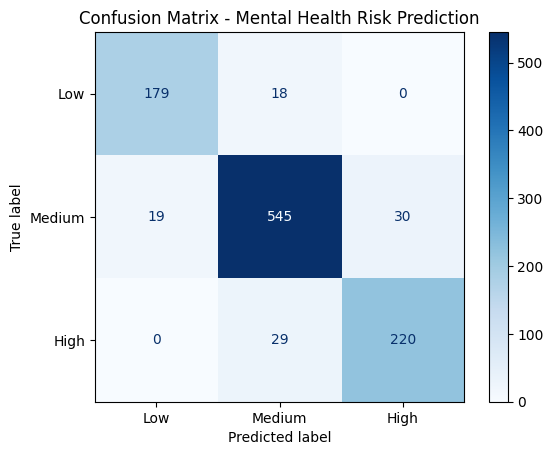

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Mental Health Risk Prediction")
plt.show()

In [6]:
import joblib

joblib.dump(model, "risk_model.pkl")

['risk_model.pkl']

In [ ]:
#from google.colab import files
#files.download("risk_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>